<a href="https://colab.research.google.com/github/daisylomo/ai-ml-projects/blob/data-preprocessing/Copy_of_DataPreprocessing_exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

      age  gender  impluse  pressurehight  pressurelow  glucose    kcm  \
0      64       1       66            160           83    160.0   1.80   
1      21       1       94             98           46    296.0   6.75   
2      55       1       64            160           77    270.0   1.99   
3      64       1       70            120           55    270.0  13.87   
4      55       1       64            112           65    300.0   1.08   
...   ...     ...      ...            ...          ...      ...    ...   
1314   44       1       94            122           67    204.0   1.63   
1315   66       1       84            125           55    149.0   1.33   
1316   45       1       85            168          104     96.0   1.24   
1317   54       1       58            117           68    443.0   5.80   
1318   51       1       94            157           79    134.0  50.89   

      troponin     class  
0        0.012  negative  
1        1.060  positive  
2        0.003  negative  
3  

/tmp/ipykernel_1515/2593931494.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="class", palette="Set2", ax=axes[0, 0])
/tmp/ipykernel_1515/2593931494.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y="troponin", palette="Set2", ax=axes[1, 0])


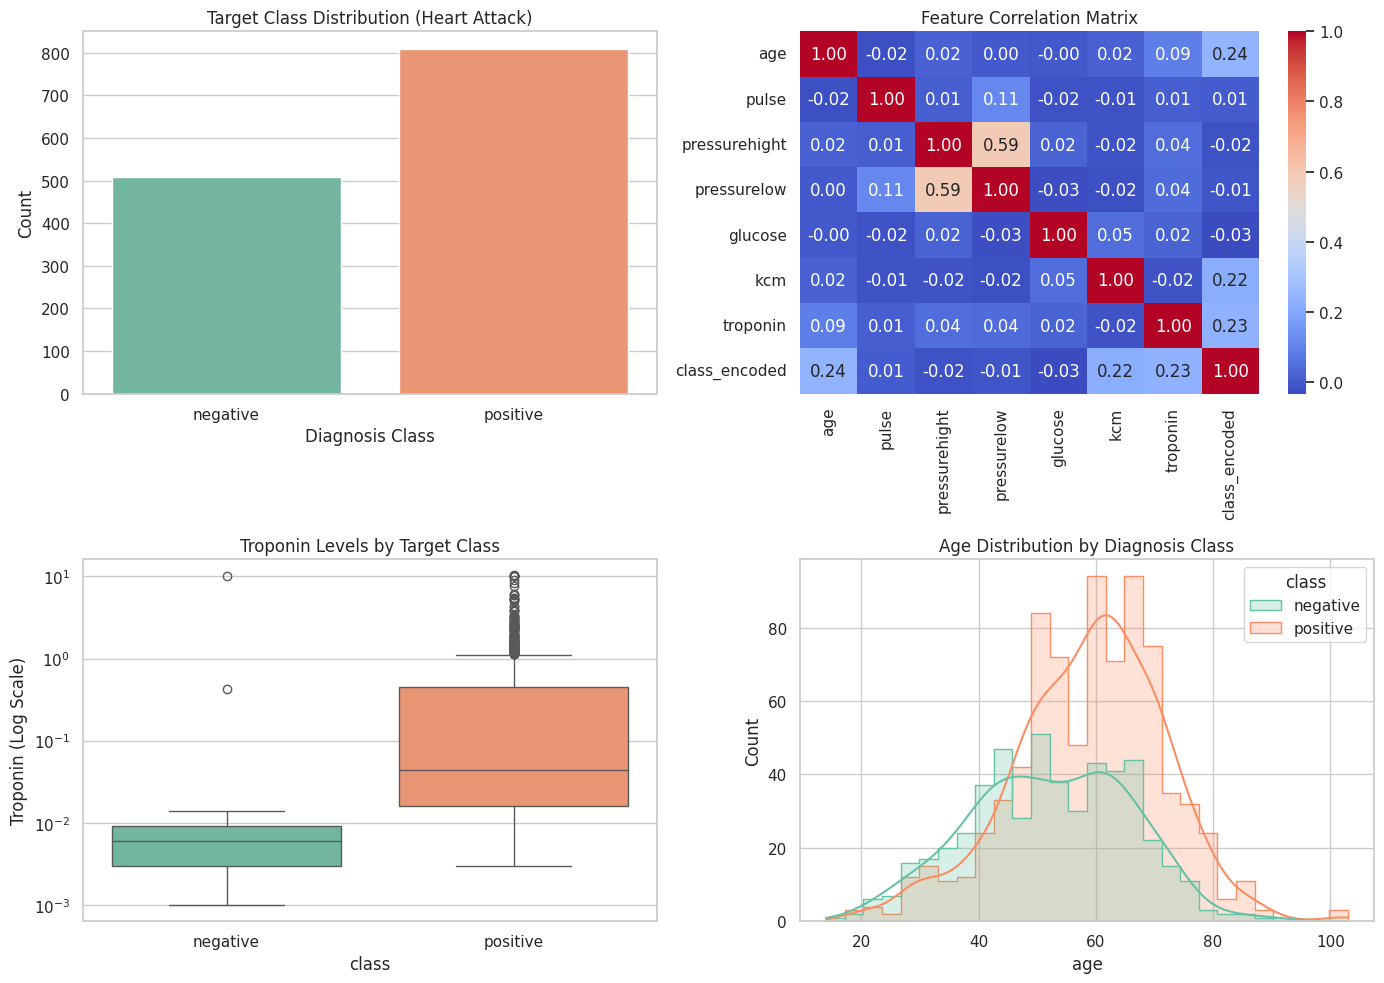

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. DATA LOADING & PREPROCESSING ---

# Load dataset
df = pd.read_csv("/content/Heart Attack.csv")
print(df)

# Clean column names (e.g., correct 'impluse' to 'pulse')
df.rename(columns={"impluse": "pulse"}, inplace=True)
#inplace=True modifies the original df directly while =False returns a new df copy w/ renamed columns

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values if any exist
num_cols = [
    "age",
    "pulse",
    "pressurehight",
    "pressurelow",
    "glucose",
    "kcm",
    "troponin",
]
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Binary encode target feature: 'negative' -> 0, 'positive' -> 1
df["class_encoded"] = df["class"].map({"negative": 0, "positive": 1})

# Separate features and target
X = df.drop(columns=["class", "class_encoded"])
y = df["class_encoded"]

# Feature Scaling (Standardization for continuous numerical variables)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Preprocessing Complete. Training shape: {X_train.shape}, Test shape: {X_test.shape}")


# --- 2. DATA VISUALIZATION ---

sns.set_theme(style="whitegrid") #just seaborn styling, whitegrid is exactly as it sounds but with grey lines
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) #no. of plots(2x2) within the figure of size 14x10 inches

# Visual 1: Target Class Balance
sns.countplot(data=df, x="class", palette="Set2", ax=axes[0, 0])
#axes refer to a specific subplot in the figure
axes[0, 0].set_title("Target Class Distribution (Heart Attack)")
axes[0, 0].set_xlabel("Diagnosis Class")
axes[0, 0].set_ylabel("Count")

# Visual 2: Correlation Heatmap
corr = df[num_cols + ["class_encoded"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0, 1])
axes[0, 1].set_title("Feature Correlation Matrix")

# Visual 3: Troponin Distribution across Classes (Log Scale)
sns.boxplot(data=df, x="class", y="troponin", palette="Set2", ax=axes[1, 0])
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Troponin Levels by Target Class")
axes[1, 0].set_ylabel("Troponin (Log Scale)")

# Visual 4: Age Distribution by Heart Attack Class
sns.histplot(
    data=df,
    x="age",
    hue="class",
    kde=True,
    element="step",
    palette="Set2",
    ax=axes[1, 1],
) #most args depend on whether dat is univariate
axes[1, 1].set_title("Age Distribution by Diagnosis Class")

plt.tight_layout()
plt.show()

Test Accuracy: 0.8106
ROC-AUC Score: 0.8965

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.79      0.76       102
           1       0.86      0.82      0.84       162

    accuracy                           0.81       264
   macro avg       0.80      0.81      0.80       264
weighted avg       0.81      0.81      0.81       264



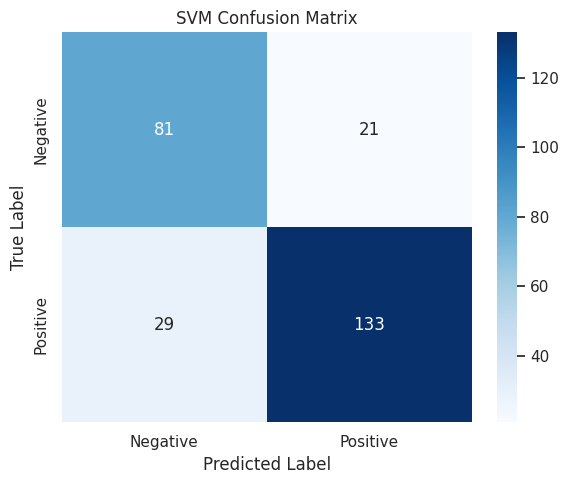

In [ ]:
"""
-- no need to repeat imports since they are retained in the kernel
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
"""
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, fbeta_score
from sklearn.svm import SVC

# --- 1. DATA PREPARATION ---
df = pd.read_csv("/content/Heart Attack.csv")

# Clean column names & drop duplicate entries
df.rename(columns={"impluse": "pulse"}, inplace=True)
df.drop_duplicates(inplace=True)

# Map binary class target ('negative': 0, 'positive': 1)
df["target"] = df["class"].map({"negative": 0, "positive": 1})

# Feature and Target Split
X = df.drop(columns=["class", "target"])
y = df["target"]

# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling (Crucial for distance-based algorithms like SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#supporting vectors on margin on opposite sides of hyperplane

# --- 2. SVM MODEL TRAINING & EVALUATION ---
# Using Radial Basis Function (RBF) kernel
svm_model = SVC(kernel="linear", C=1.0, probability=True, random_state=42) #kernel type specifies the shape of the hyperplanes
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = svm_model.predict(X_test_scaled) #discrete class labels
y_proba = svm_model.predict_proba(X_test_scaled)[:, 1] #probabilities

# Display Performance Metrics --use libraries in sklearn
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# --- 3. CONFUSION MATRIX VISUALIZATION ---
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=ax,
)
ax.set_title("SVM Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Test Accuracy: 0.9356
ROC-AUC Score: 0.9748

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92       102
           1       0.94      0.95      0.95       162

    accuracy                           0.94       264
   macro avg       0.93      0.93      0.93       264
weighted avg       0.94      0.94      0.94       264



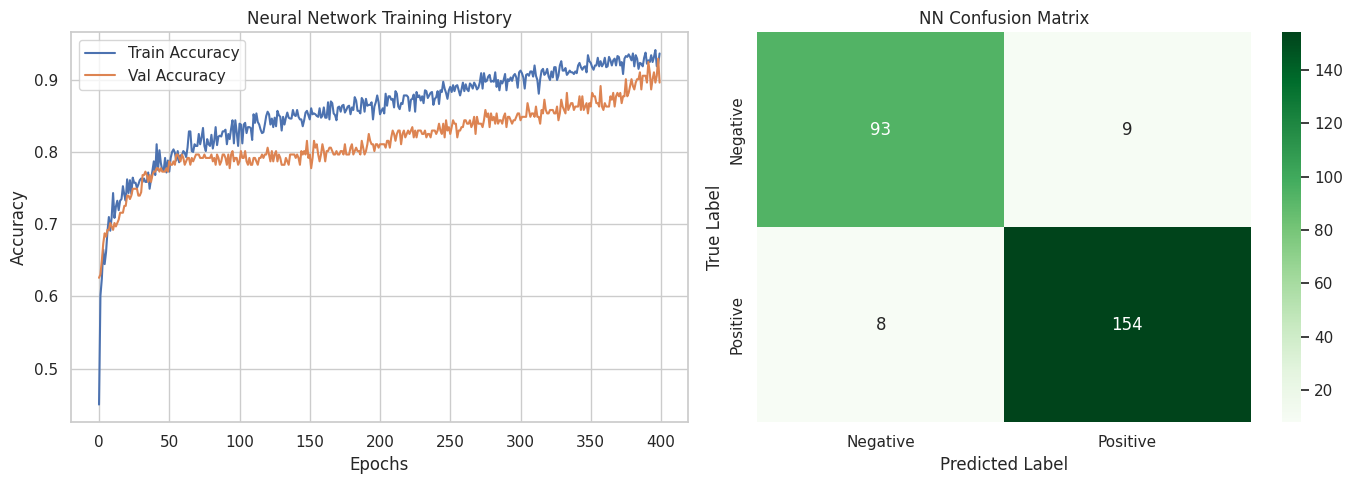

In [ ]:
"""
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
"""
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

"""
# --- 1. DATA PREPARATION ---
df = pd.read_csv("/content/Heart Attack.csv")

# Clean column names & drop duplicates
df.rename(columns={"impluse": "pulse"}, inplace=True)
df.drop_duplicates(inplace=True)

# Encode target variable
df["target"] = df["class"].map({"negative": 0, "positive": 1})

# Feature & Target Split
X = df.drop(columns=["class", "target"])
y = df["target"]

# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
"""
# --- 2. BUILD NEURAL NETWORK ARCHITECTURE ---
model = Sequential(
    [
        Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.2),  # Prevents overfitting by randomly deactivating a %age of neurons
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid"),  # Binary classification output
    ]
)

model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
) #optimizer updates a model's weights & biases

# --- 3. MODEL TRAINING ---
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=400,
    batch_size=32,
    verbose=0,
)

# --- 4. EVALUATION & PREDICTIONS ---
y_proba = model.predict(X_test_scaled).ravel() #flattens 2d to 1d
y_pred = (y_proba >= 0.5).astype(int)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# --- 5. VISUALIZATIONS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Learning Curves
axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Neural Network Training History")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Plot 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=axes[1],
)
axes[1].set_title("NN Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [ ]:
#--- K-NN ---
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)
y_proba = knn_model.predict_proba(X_test_scaled)[:, 1]

test_accuracy_knn = accuracy_score(y_test, y_pred)
roc_auc_knn = roc_auc_score(y_test, y_proba)
f_score_knn = fbeta_score(y_test, y_pred, beta=0.5)
classification_report_knn = classification_report(y_test, y_pred)

print(f"Classification Report:\n {classification_report_knn}")

Test Accuracy: 0.6667
ROC-AUC Score: 0.7316
F-score: 0.7373

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.65      0.60       102
           1       0.75      0.68      0.71       162

    accuracy                           0.67       264
   macro avg       0.66      0.66      0.66       264
weighted avg       0.68      0.67      0.67       264



In [ ]:
#--- Random Forest ---
from sklearn.ensemble import RandomForestClassifier

rforest_model = RandomForestClassifier()
rforest_model.fit(X_train_scaled, y_train)

y_pred = rforest_model.predict(X_test_scaled)
y_proba = rforest_model.predict_proba(X_test_scaled)[:, 1]

test_accuracy_rfrst = accuracy_score(y_test, y_pred)
roc_auc_rfrst = roc_auc_score(y_test, y_proba)
f_score_rfrst = fbeta_score(y_test, y_pred, beta=0.5)
classification_report_rfrst = classification_report(y_test, y_pred)

print(f"Classification Report:\n {classification_report_rfrst}")

Test Accuracy: 0.9848
ROC-AUC Score: 0.9959
F-score: 0.9877

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       102
           1       0.99      0.99      0.99       162

    accuracy                           0.98       264
   macro avg       0.98      0.98      0.98       264
weighted avg       0.98      0.98      0.98       264



In [ ]:
#---Naive Bayes ---
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)
y_proba = nb_model.predict_proba(X_test_scaled)[:, 1]

test_accuracy_nb = accuracy_score(y_test, y_pred)
roc_auc_nb = roc_auc_score(y_test, y_proba)
f_score_nb = fbeta_score(y_test, y_pred, beta=0.5)
classification_report_nb = classification_report(y_test, y_pred)

print(f"Classification Report:\n {classification_report_nb}")

Test Accuracy: 0.6970
ROC-AUC Score: 0.8483
F-score: 0.8333

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.99      0.72       102
           1       0.99      0.51      0.67       162

    accuracy                           0.70       264
   macro avg       0.77      0.75      0.70       264
weighted avg       0.82      0.70      0.69       264



In [ ]:
#--- Comparison of Model Performance/Model Eval ---
#1. Precision
#2. Recall
#3. ROC-AUC
#4. F-score

"""
f score uses weighted harmonic mean(when one mistake is costlier than the other) while f1 score uses balanced harmonic mean
"""



In [ ]:
model_scores = {
    "test_accuracy": [
        test_accuracy_knn,
        test_accuracy_rfrst,
        test_accuracy_nb,
    ],
    "roc_auc": [
        roc_auc_knn,
        roc_auc_rfrst,
        roc_auc_nb,
    ],
    "f_score": [
        f_score_knn,
        f_score_rfrst,
        f_score_nb,
    ],
}
df_model_scores = pd.DataFrame(model_scores).set_index(pd.Index(["KNN", "Random Forest", "Naive Bayes"]))
print(df_model_scores)


               test_accuracy   roc_auc   f_score
KNN                 0.666667  0.731572  0.737265
Random Forest       0.984848  0.995945  0.987654
Naive Bayes         0.696970  0.848342  0.833333


Among the three models, we can infer that Random Forest is the best suited algorithm with highest scores

KNN is the lowest performing model among the three